In [3]:
import torch
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.utils import load_full_config

Loaded 71000 samples.
History length: 20 (config: 20)
Target length: 10 (config: 10)


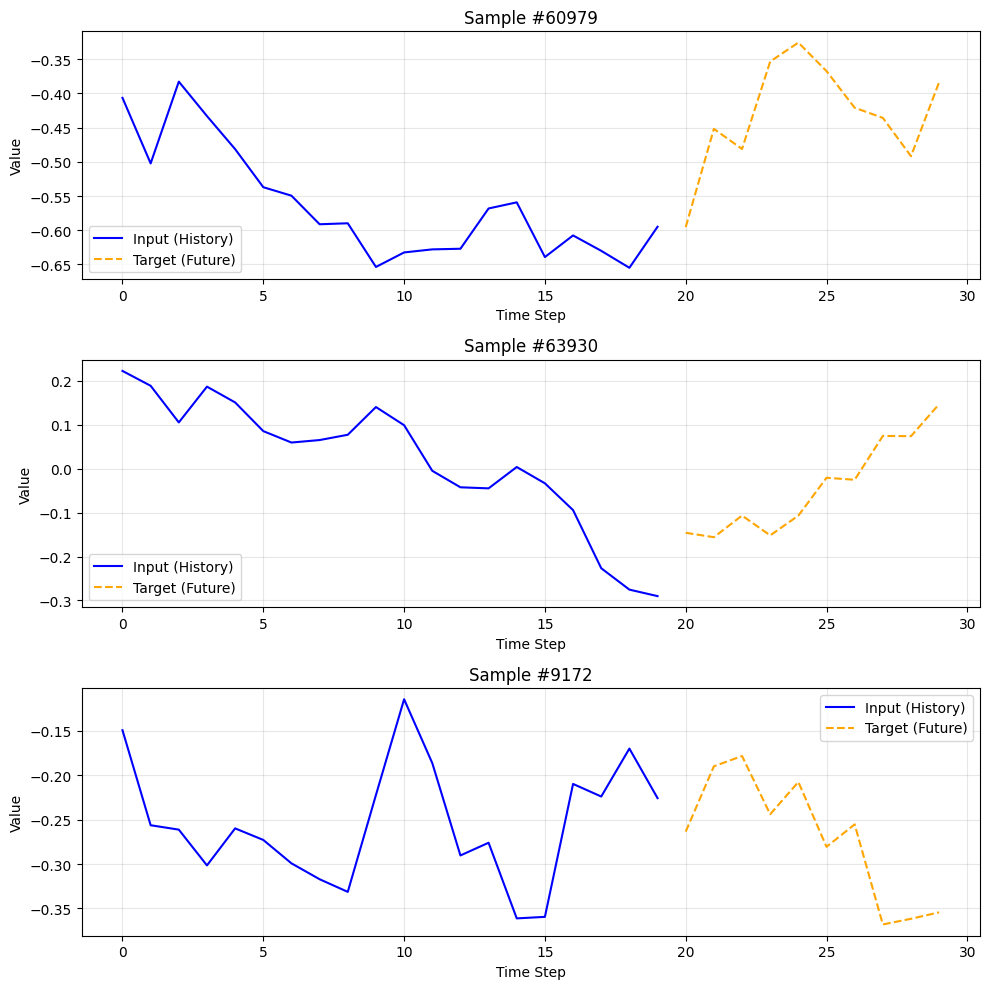

In [4]:
# Load config and data
cfg = load_full_config()
checkpoint = torch.load('../data/ou_dataset.pt')
X = checkpoint['X']
Y = checkpoint['Y']

input_len = cfg['windowing']['input_len']
output_len = cfg['windowing']['output_len']

print(f"Loaded {X.shape[0]} samples.")
print(f"History length: {X.shape[1]} (config: {input_len})")
print(f"Target length: {Y.shape[1]} (config: {output_len})")

fig, axs = plt.subplots(3, 1, figsize=(10, 10))

for i in range(3):
    # Pick a random index
    idx = torch.randint(0, len(X), (1,)).item()
    
    # Get the data (convert to numpy for plotting)
    history = X[idx].numpy().flatten()
    future = Y[idx].numpy().flatten()
    
    # Create the time axis dynamically from config
    t_history = range(0, input_len)
    t_future = range(input_len, input_len + output_len)
    
    # Plot
    axs[i].plot(t_history, history, label='Input (History)', color='blue')
    axs[i].plot(t_future, future, label='Target (Future)', color='orange', linestyle='--')
    axs[i].set_title(f"Sample #{idx}")
    axs[i].set_xlabel('Time Step')
    axs[i].set_ylabel('Value')
    axs[i].legend()
    axs[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()